In [1]:
import pandas as pd

df_pats = pd.read_csv("Imp_Results/imputation_results_by_patient.csv")
print("Registros:", len(df_pats))

Registros: 5250


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

#removing the outiler 400 > rmse on MLP with 20MR
print(len(df_pats[df_pats["mean_rmse"] > 100]))
df_pats = df_pats[df_pats["mean_rmse"] < 100]

# ======================
# Agrupamentos
# ======================
df_grouped = (
    df_pats
    .groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse']
    .mean()
    .reset_index()
)

df_memory = (
    df_pats
    .groupby(['mechanism', 'patient', 'imputer'])['memory']
    .mean()
    .reset_index()
)

# ======================
# Ordens
# ======================
order_mec = ['MCAR' , 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
order_imputers = [
    'mean',
    'reg_opt_00001',
    'tree_gp_10000',
    'tree-ad_gp_5000-dw_30000',
    'mlp_opt_0001'
]

# ======================
# Labels bonitos dos imputers
# ======================
new_labels = {
    'mean': 'Mean',
    'reg_opt_00001': 'LR',
    'tree_gp_10000': 'HT',
    'tree-ad_gp_5000-dw_30000': 'HAT',
    'mlp_opt_0001': 'MLP',
}
pretty_imputers = [new_labels[i] for i in order_imputers]

# ======================
# Labels LaTeX dos mechanisms
# ======================
mec_labels = {}
for mec in order_mec:
    if mec == 'MCAR':
        mec_labels[mec] = 'MCAR'
        continue
    base, sub = mec.split("_", 1)
    mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"

df_grouped['mechanism_label'] = df_grouped['mechanism'].map(mec_labels)
df_memory['mechanism_label'] = df_memory['mechanism'].map(mec_labels)

pal = sns.light_palette("purple", n_colors=7)
pal = pal[1:7]


2


/tmp/ipykernel_1622194/4032372981.py:14: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  g = sns.catplot(


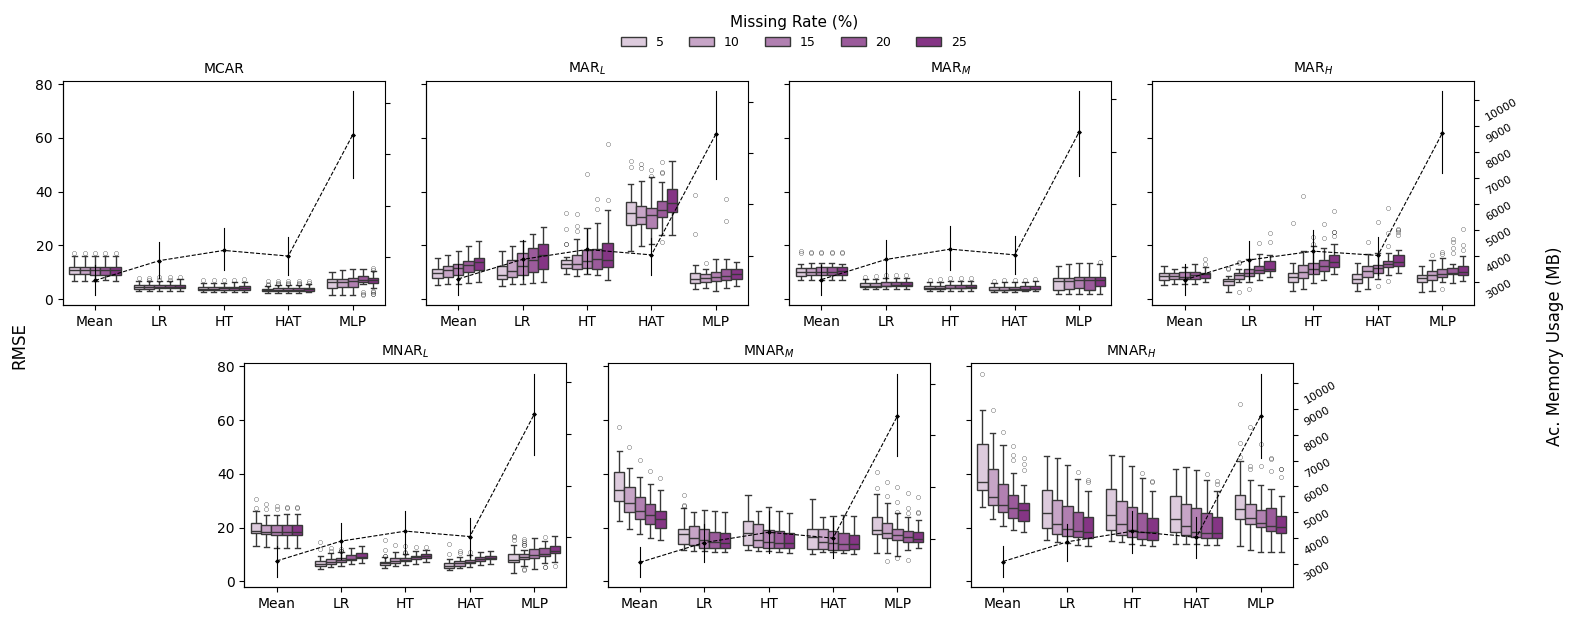

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================
# Layout
# ======================
order_mec = ["MCAR", "MAR_l", "MAR_m", "MAR_h",
             "MNAR_l", "MNAR_m", "MNAR_h"]

order_mec = [m for m in order_mec
             if mec_labels[m] in df_grouped["mechanism_label"].unique()]

g = sns.catplot(
    data=df_grouped,
    x="imputer",
    y="mean_rmse",
    hue="missing_rate",
    col="mechanism_label",
    col_order=[mec_labels[m] for m in order_mec],
    col_wrap=4,
    order=order_imputers,
    kind="box",
    palette=pal,
    width=0.8,
    height=3,
    aspect=1.2,
    flierprops=dict(
        marker="o",
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor="black",
    ),
)

axes = g.axes.flatten()
ncols = 4

# ======================
# Segundo eixo (Memória)
# ======================
for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):

    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='black',
        markers='D',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
    )

    row = i // ncols
    col = i % ncols

    # ----------------------
    # Eixo Y esquerdo → apenas primeira coluna
    # ----------------------
    if col == 0:
        ax.tick_params(axis='y', labelleft=True)
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.set_ylabel("")

    # ----------------------
    # Eixo Y direito → apenas última coluna
    # ----------------------
    if col == ncols - 1 or i == len(axes) - 1:
        ax2.tick_params(axis='y',
                        labelright=True,
                        labelrotation=30,
                        labelsize=8)
    else:
        ax2.tick_params(axis='y', labelright=False)

    ax2.set_ylabel("")

# ======================
# Legenda superior
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()
g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.07),
    fontsize=9,
    title_fontsize=11
)

# ======================
# Rótulos X em todos
# ======================
g.set_titles(col_template="{col_name}")
g.set_xlabels("")

for ax in axes:
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=0)
    ax.tick_params(axis='x', labelbottom=True)

# ======================
# Centralizar última linha
# ======================
# ======================
plt.draw()  # IMPORTANTE

nplots = len(axes)
ncols = 4

if nplots % ncols != 0:

    n_last = nplots % ncols
    start = nplots - n_last

    first_row = axes[:ncols]

    left_edge = first_row[0].get_position().x0
    right_edge = first_row[-1].get_position().x1
    total_width = right_edge - left_edge

    single_width = first_row[0].get_position().width
    spacing = first_row[1].get_position().x0 - first_row[0].get_position().x1

    occupied_width = n_last * single_width + (n_last - 1) * spacing
    new_left = left_edge + (total_width - occupied_width) / 2

    for i in range(n_last):

        ax = axes[start + i]
        pos = ax.get_position()

        new_x = new_left + i * (single_width + spacing)

        # mover eixo principal
        ax.set_position([new_x, pos.y0, single_width, pos.height])

        # mover eixo twin correspondente
        twin_ax = ax.figure.axes[len(axes) + (start + i)]
        twin_ax.set_position([new_x, pos.y0, single_width, pos.height])

# ======================
# Labels globais centralizados
# ======================
g.figure.text(
    0.01, 0.5,
    "RMSE",
    va='center',
    rotation='vertical',
    fontsize=12
)

g.figure.text(
    0.97, 0.5,
    "Ac. Memory Usage (MB)",
    va='center',
    rotation='vertical',
    fontsize=12
)

# ======================
# Ajustes finais
# ======================
g.figure.set_size_inches(16, 6)


plt.savefig(
    "Plots/boxplot_imputers_box.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

/tmp/ipykernel_1283854/522776739.py:24: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  return _original_catplot(*args, **kwargs)


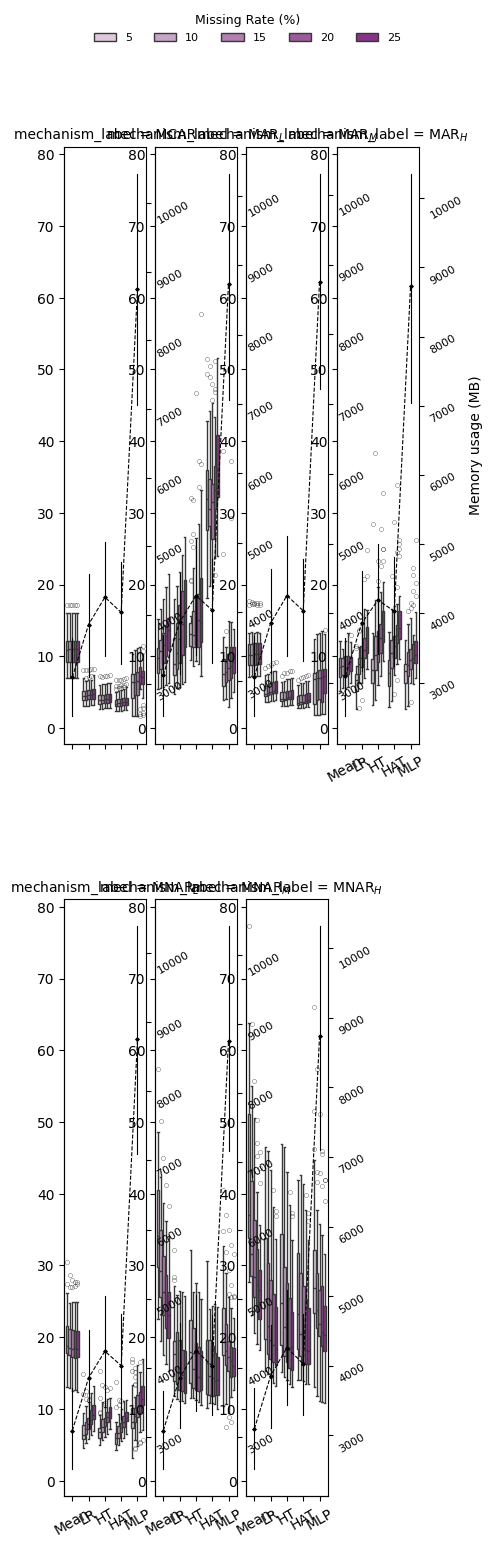

In [30]:
import seaborn as sns

g = sns.catplot(
    data=df_grouped,
    x='imputer',
    y='mean_rmse',
    hue='missing_rate',
    row='mechanism_label',
    row_order=[mec_labels[mec] for mec in order_mec],
    order=order_imputers,
    kind='box',
    palette=pal,
    width=0.8,
    height=3,
    aspect=4,
    flierprops=dict(
        marker='o',
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor='black'
    ),
)

# ======================
# Segundo eixo Y (memória)
# ======================
axes = g.axes.flat

for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):
    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='black',
        markers='D',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
        
    )

    ax2.tick_params(axis='y', labelrotation=30, labelsize=8, labelcolor='black')

    if i == 3:
        ax2.set_ylabel('Memory usage (MB)')
        ax2.set_xlabel('RMSE')
    else:
        ax2.set_ylabel('')
        ax2.set_xlabel('')

# ======================
# Legenda (missing rate) em cima — versão robusta
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()

g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
    fontsize=8,
    title_fontsize=9
)

# ======================
# Eixos e títulos
# ======================
for idx, ax in enumerate(g.axes.flat):
    ax.set_ylabel("RMSE" if idx == 3 else "")
g.set_titles(row_template="{row_name}", size=10)
g.set_xlabels("")

for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=30)

# ======================
# Tamanho e salvamento
# ======================
g.figure.set_size_inches(4, 16)
plt.savefig("Plots/boxplot_imputers_vertical.png", bbox_inches='tight', dpi=300)
plt.show()


In [23]:

# ======================
# Catplot horizontal
# ======================
g = sns.catplot(
    data=df_grouped,
    x='imputer',
    y='mean_rmse',
    hue='missing_rate',
    col='mechanism',
    col_order=order_mec,
    order=order_imputers,
    kind='box',
    palette='Set2',
    width=0.6,
    height=3.0,
    aspect=1.1,
    flierprops=dict(
        marker='o',
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor='black'
    )
)

# ======================
# Segundo eixo Y (memória)
# ======================
axes = g.axes.flat

for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):
    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='black',
        markers='x',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
        # errorbar=None
    )

    # eixo de memória só no último painel (direita)
    if i == len(order_mec) - 1:
        ax2.set_ylabel('Memory usage (MB)')
        ax2.tick_params(axis='y', labelrotation=45, labelsize=8, labelcolor='black')
    else:
        ax2.set_ylabel('')
        ax2.set_yticks([])
        ax2.spines['right'].set_visible(True)

# ======================
# Legenda do missing rate em cima
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()

g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.09),
    fontsize=9,
    title_fontsize=10,
    columnspacing=1.0
)

# ======================
# Eixos e títulos
# ======================
g.set_axis_labels("", "RMSE")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=30)

    mec = ax.get_title()
    ax.set_title(mec_labels.get(mec, mec))

# ======================
# Tamanho e salvamento
# ======================
g.figure.set_size_inches(19, 4)
plt.savefig(
    "Plots/boxplot_imputers_horizontal.png",
    bbox_inches='tight',
    dpi=300
)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

CD-Diagrams

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cd_diagram import draw_cd_diagram

In [32]:
df = pd.read_csv("Imp_Results/imputation_results_by_patient.csv")
df_pats = df_pats[df_pats["mean_rmse"] < 100]

new_labels = {
    'mean': 'Mean',
    'reg_opt_00001': 'LR',
    'tree-ad_gp_5000-dw_30000': 'HAT',
    'tree_gp_10000': 'HT',
    'mlp_opt_0001': 'MLP',
}

df['imputer'] = df['imputer'].map(new_labels)

mechanisms = df['mechanism'].unique()
mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_", 1)
        mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_labels[mec] = mec

df_crit= df.groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse'].mean().reset_index()
df_crit['dataset_name'] = df_crit['mechanism'] + '_' + df_crit['patient'] + '_' + df_crit['missing_rate'].astype(str)
df_crit = df_crit.rename(columns={'imputer': 'classifier_name'})
df_crit = df_crit.rename(columns={'mean_rmse': 'accuracy'})
df_crit['accuracy'] = df_crit['accuracy'] * -1
df_crit = df_crit.drop(columns=['patient', 'missing_rate'])
df_crit = df_crit[['classifier_name', 'dataset_name', 'accuracy', 'mechanism']]

In [33]:
dfs = {}

for mec in df_crit['mechanism'].unique():
    dfs[mec] = df_crit[df_crit['mechanism'] == mec].drop(columns=['mechanism'])

for mec, df_mec in dfs.items():
    draw_cd_diagram(df_perf=df_mec, title=f"{mec_labels[mec]}", labels=False, save_path=f"Plots/CD_Diagrams/CD-{mec}.png")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found

['HAT' 'HT' 'LR' 'MLP' 'Mean']
HAT      3.0
HT       2.0
LR      24.0
MLP     28.0
Mean    91.0
dtype: float64
HAT     4.136667
HT      3.930000
MLP     2.513333
LR      2.480000
Mean    1.940000
dtype: float64
('HAT', 'LR', np.float64(1.969144941098984e-22), True)
('HT', 'LR', np.float64(5.709281021983329e-18), True)
('HT', 'Mean', np.float64(2.2916000474086083e-16), True)
('HAT', 'Mean', np.float64(3.4090963257734793e-16), True)
('HAT', 'MLP', np.float64(3.0543315639670495e-15), True)
('HT', 'MLP', np.float64(5.313954370774989e-15), True)
('MLP', 'Mean', np.float64(1.8471818454021218e-07), True)
('LR', 'Mean', np.float64(1.1224286763443266e-06), True)
('HAT', 'HT', np.float64(0.29512448175572026), False)
('LR', 'MLP', np.float64(0.44229314011361953), False)
Index(['HAT', 'HT', 'MLP', 'LR', 'Mean'], dtype='object')
[0, 1]
[2, 3]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean']
HAT       0.0
HT        7.0
LR       22.0
MLP     108.0
Mean     13.0
dtype: float64
HAT     4.973333
HT      3.286667
LR      2.813333
Mean    2.500000
MLP     1.426667
dtype: float64
('HAT', 'Mean', np.float64(2.299490546562069e-26), True)
('HAT', 'LR', np.float64(2.2995481506182782e-26), True)
('HAT', 'HT', np.float64(1.937964636810414e-25), True)
('HAT', 'MLP', np.float64(4.976811852322073e-25), True)
('HT', 'MLP', np.float64(1.1206454003463582e-20), True)
('MLP', 'Mean', np.float64(5.85840297722442e-17), True)
('LR', 'MLP', np.float64(2.946367915643811e-14), True)
('HT', 'Mean', np.float64(2.6067923075848372e-12), True)
('LR', 'Mean', np.float64(1.4401343104867574e-07), True)
('HT', 'LR', np.float64(0.001206010502500611), True)
Index(['HAT', 'HT', 'LR', 'Mean', 'MLP'], dtype='object')


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

['HAT' 'HT' 'LR' 'MLP' 'Mean']
HAT     93.0
HT      13.0
LR      16.0
MLP     28.0
Mean     0.0
dtype: float64
Mean    5.000000
MLP     3.433333
HT      2.626667
LR      2.493333
HAT     1.446667
dtype: float64
('MLP', 'Mean', np.float64(2.2992025471682047e-26), True)
('LR', 'Mean', np.float64(2.2992601442621799e-26), True)
('HT', 'Mean', np.float64(2.2993753426271887e-26), True)
('HAT', 'Mean', np.float64(2.2995481506182782e-26), True)
('HAT', 'LR', np.float64(1.3592511795392997e-22), True)
('HAT', 'HT', np.float64(3.272435688459362e-19), True)
('HAT', 'MLP', np.float64(7.016239925498077e-19), True)
('LR', 'MLP', np.float64(1.2756669318325262e-11), True)
('HT', 'MLP', np.float64(5.069213084573021e-10), True)
('HT', 'LR', np.float64(0.009359862783949312), True)
Index(['Mean', 'MLP', 'HT', 'LR', 'HAT'], dtype='object')


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Gene

['HAT' 'HT' 'LR' 'MLP' 'Mean']
HAT     102.0
HT        6.0
LR        5.0
MLP      36.0
Mean      0.0
dtype: float64
Mean    5.000000
MLP     3.246667
LR      2.753333
HT      2.663333
HAT     1.336667
dtype: float64
('HAT', 'Mean', np.float64(2.2994329438983904e-26), True)
('LR', 'Mean', np.float64(2.2994329438983904e-26), True)
('HT', 'Mean', np.float64(2.299490546562069e-26), True)
('MLP', 'Mean', np.float64(2.2995481506182782e-26), True)
('HAT', 'LR', np.float64(1.3838704886346672e-25), True)
('HAT', 'HT', np.float64(3.260482255256221e-25), True)
('HAT', 'MLP', np.float64(9.087337316479121e-09), True)
('HT', 'MLP', np.float64(0.00011674316894943626), True)
('LR', 'MLP', np.float64(0.000183123818716554), True)
('HT', 'LR', np.float64(0.18281130105915555), False)
Index(['Mean', 'MLP', 'LR', 'HT', 'HAT'], dtype='object')
[2, 3]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.


In [34]:
from PIL import Image

# List of CD diagram images in order
image_files = [f"Plots/CD_Diagrams/CD-{mec}.png" for mec in mechanisms]

# Open all images
images = [Image.open(img_file) for img_file in image_files]

# Get dimensions
widths, heights = zip(*(img.size for img in images))

# Calculate total height and max width
total_height = sum(heights)
max_width = max(widths)

# Create new image with combined height
combined_image = Image.new('RGB', (max_width, total_height), 'white')

# Paste images one below the other
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.size[1]

# Save combined image
combined_image.save('Plots/CD_Diagrams/CD-all-mechanisms.png')
print("Combined image saved as CD-all-mechanisms.png")

Combined image saved as CD-all-mechanisms.png
